Ridge regularization adds a penalty to the sum of the squared values of the coefficients. This encourages the coefficients to be small but non-zero rather than zero.

Unlike Lasso, Ridge doesn’t perform feature selection, but instead shrinks the coefficients toward zero, which can help with multicollinearity (correlated features).

Formula for Ridge (L2 Regularization): Cost/Loss function = MSE + α ∑wi² 
α is the regularization strength,
wi² is the square of the coefficients.

Ridge does not zero out any features; it shrinks them

Ridge might need a larger alpha.

Used to reduce Overfitting.


In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import fetch_california_housing


In [31]:
data = fetch_california_housing()
df = pd.DataFrame(data.data,columns=data.feature_names)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [32]:
x = df
y = data.target

In [33]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.30,random_state=42)

In [34]:
sc_x = StandardScaler()
x_train = sc_x.fit_transform(x_train)
x_test = sc_x.transform(x_test)
sc_y = StandardScaler()
y_train = sc_y.fit_transform(np.array(y_train).reshape(-1,1))

In [35]:
regressor = Ridge()

In [47]:
# parameters = {'alpha':[1,2,3,4,5,6,7,8,9,10,15,20,25,30,35,47,55,70,80,93,99]}
alphas = np.logspace(-2, 4, 100)    
ridgecv = GridSearchCV(regressor,{'alpha':alphas},scoring='neg_mean_squared_error',cv=5)
ridgecv.fit(x_train,y_train)

,estimator,Ridge()
,param_grid,{'alpha': array([1.0000...00000000e+04])}
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,np.float64(6.135907273413176)


In [48]:
ridgecv.best_params_

{'alpha': np.float64(6.135907273413176)}

In [49]:
ridgecv.best_score_

np.float64(-0.39323668372665915)

In [50]:
y_pred_sc = ridgecv.predict(x_test)
y_pred = sc_y.inverse_transform(y_pred_sc.reshape(-1,1))

In [51]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [52]:
score = r2_score(y_test,y_pred) 
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R²: 0.5958793458028628
MAE: 0.5272230156888537
MSE: 0.5304245670297193


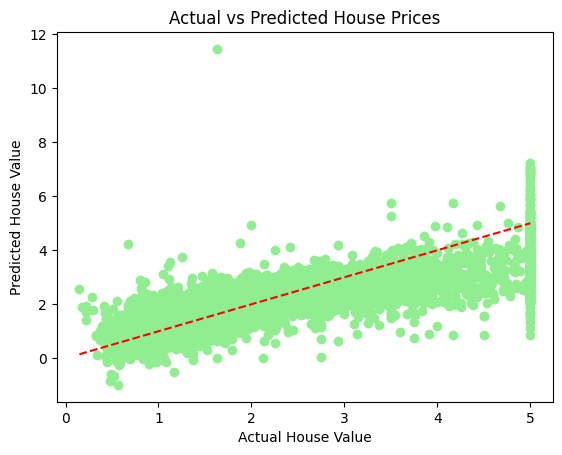

In [53]:
plt.scatter(y_test,y_pred,color="lightgreen")
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color="red",linestyle="--")
plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.title('Actual vs Predicted House Prices')
plt.show()

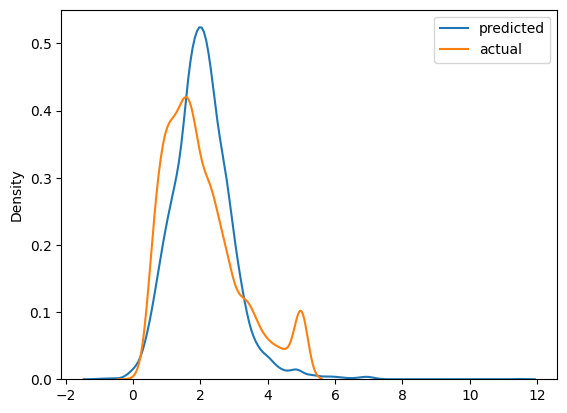

In [54]:
import seaborn as sns
sns.kdeplot(y_pred,label="predicted")
sns.kdeplot(y_test,label="actual")
plt.legend()

In [56]:
ridge_coef = ridgecv.best_estimator_.coef_
print("Number of zero coefficients in Ridge:", np.sum(ridge_coef == 0))  

Number of zero coefficients in Ridge: 0
